<a href="https://colab.research.google.com/github/aayushijain28/aayushijain_ml2_lab/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'household-power-consumption' dataset.
Original shape: (2075259, 9)


/tmp/ipykernel_774/2776758522.py:88: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(


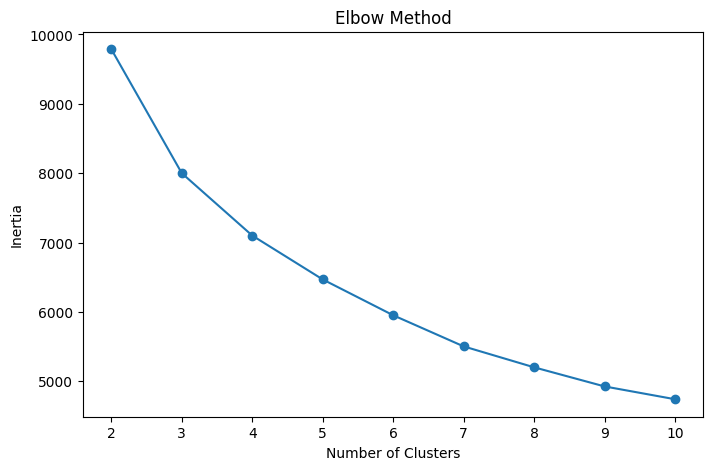

Silhouette Score: 0.22950837065077812

Cluster Counts:
Cluster
0    342
1    302
2    798
Name: count, dtype: int64

Cluster Summary:
         active_power_mean  active_power_max  active_power_std  \
Cluster                                                          
0                 1.584406          7.208386          1.307863   
1                 0.589366          3.183854          0.512335   
2                 1.068321          5.437494          0.906019   

         reactive_power_mean  voltage_mean  intensity_mean  intensity_max  \
Cluster                                                                     
0                   0.135128    240.868470        6.689228      30.872515   
1                   0.126480    240.656799        2.551749      13.517881   
2                   0.117691    240.886418        4.520763      23.118296   

         sub_metering_1  sub_metering_2  sub_metering_3  
Cluster                                                  
0              2.155974        2.

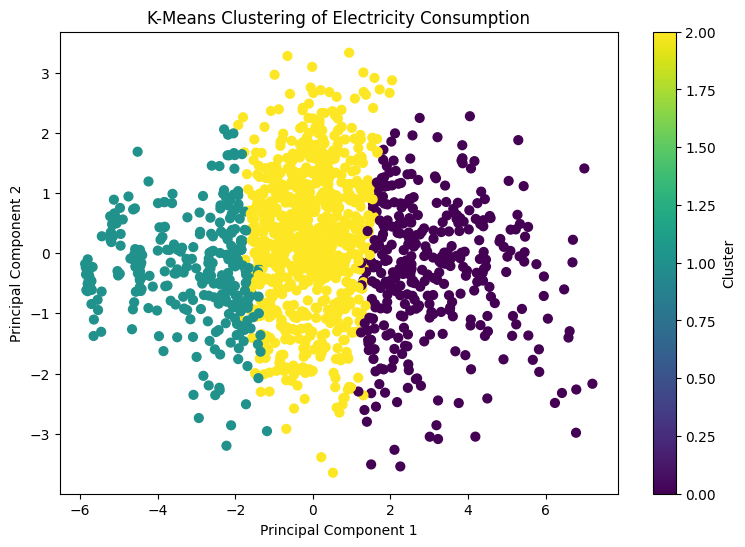


Clustered dataset saved as 'electricity_kmeans_clusters.csv'


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# ==========================================
# 1. READ DATASET
# ==========================================

import kagglehub
path = kagglehub.dataset_download("ahmedashrafahmed/household-power-consumption")

# Find the dataset file within the downloaded path
# The path returned by kagglehub.dataset_download is usually a directory
# containing the extracted dataset files. We need to find the actual data file.

downloaded_contents = os.listdir(path)

dataset_file = None
# Correct the expected filename based on the error message
expected_filename = "Household_power_consumption.csv"

# Check if the exact expected filename (case-sensitive) is directly in the downloaded contents
if expected_filename in downloaded_contents:
    dataset_file = os.path.join(path, expected_filename)
else:
    # If not, search for any .csv file in the directory (case-insensitive for robustness).
    csv_files = [f for f in downloaded_contents if f.lower().endswith('.csv')]
    if len(csv_files) == 1:
        dataset_file = os.path.join(path, csv_files[0])
    elif len(csv_files) > 1:
        # If multiple .csv files, try to find a case-insensitive match for the expected filename.
        matched_csv = next((f for f in csv_files if f.lower() == expected_filename.lower()), None)
        if matched_csv:
            dataset_file = os.path.join(path, matched_csv)
        else:
            # If no specific match, just pick the first one and warn.
            dataset_file = os.path.join(path, csv_files[0])
            print(f"Warning: Multiple .csv files found in '{path}'. Using the first one: {csv_files[0]}")
    else:
        # As a fallback, search for any .txt file, in case the extension is wrong but content is correct.
        txt_files = [f for f in downloaded_contents if f.lower().endswith('.txt')]
        if len(txt_files) == 1:
            dataset_file = os.path.join(path, txt_files[0])
            print(f"Warning: No .csv files found, but found a .txt file. Using: {txt_files[0]}")
        elif len(txt_files) > 1:
             # If multiple .txt files, pick the first one and warn.
            dataset_file = os.path.join(path, txt_files[0])
            print(f"Warning: Multiple .txt files found in '{path}'. Using the first one: {txt_files[0]}")
        else:
            # If no .csv or .txt files are found at all, raise an error.
            raise FileNotFoundError(
                f"Could not find '{expected_filename}' or any other .csv/.txt file in the downloaded path: {path}. "
                f"Contents found: {downloaded_contents}"
            )

# Ensure that a dataset file was successfully identified before proceeding
if dataset_file is None or not os.path.exists(dataset_file):
    raise FileNotFoundError(
        f"Failed to locate the dataset file. Expected '{expected_filename}' or another .csv/.txt file in '{path}'. "
        f"Contents found: {downloaded_contents}"
    )

# Load the dataset into a pandas DataFrame without parsing dates yet
df = pd.read_csv(
    dataset_file,
    sep=',', # Changed separator from ';' to ','
    low_memory=False,
    na_values=['?']
)

print("Original shape:", df.shape)


# ==========================================
# 2. CREATE DATETIME
# ==========================================

# The 'df' now contains a column named 'datetime' (lowercase) which needs to be converted and renamed.
# Convert the 'datetime' column to datetime objects
df['datetime'] = pd.to_datetime(
    df['datetime'],
    dayfirst=True,
    errors='coerce' # Handle any parsing errors by setting to NaT
)

# Rename 'datetime' to 'Datetime' to match notebook's convention
df = df.rename(columns={'datetime': 'Datetime'})

# Drop rows where Datetime conversion failed
df = df.dropna(subset=['Datetime'])


# ==========================================
# 3. CONVERT NUMERICAL FEATURES
# ==========================================

features = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

for col in features:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df[features] = df[features].fillna(
    df[features].median()
)


# ==========================================
# 4. CREATE DAILY FEATURES
# ==========================================

df["Date_only"] = df["Datetime"].dt.date

daily = df.groupby("Date_only").agg({

    "Global_active_power": [
        "mean",
        "max",
        "std"
    ],

    "Global_reactive_power": "mean",

    "Voltage": "mean",

    "Global_intensity": [
        "mean",
        "max"
    ],

    "Sub_metering_1": "mean",
    "Sub_metering_2": "mean",
    "Sub_metering_3": "mean"
})


daily.columns = [
    "active_power_mean",
    "active_power_max",
    "active_power_std",
    "reactive_power_mean",
    "voltage_mean",
    "intensity_mean",
    "intensity_max",
    "sub_metering_1",
    "sub_metering_2",
    "sub_metering_3"
]

daily = daily.dropna()


# ==========================================
# 5. STANDARDIZATION
# ==========================================

scaler = StandardScaler()

X = scaler.fit_transform(daily)


# ==========================================
# 6. ELBOW METHOD
# ==========================================

inertia = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(
        model.inertia_
    )


plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()


# ==========================================
# 7. K-MEANS
# ==========================================

K = 3

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

daily["Cluster"] = kmeans.fit_predict(X)


# ==========================================
# 8. SILHOUETTE SCORE
# ==========================================

score = silhouette_score(
    X,
    daily["Cluster"]
)

print(
    "Silhouette Score:",
    score
)


# ==========================================
# 9. CLUSTER COUNTS
# ==========================================

print("\nCluster Counts:")

print(
    daily["Cluster"]
    .value_counts()
    .sort_index()
)


# ==========================================
# 10. CLUSTER SUMMARY
# ==========================================

print("\nCluster Summary:")

summary = daily.groupby("Cluster").mean()

print(summary)


# ==========================================
# 11. PCA VISUALIZATION
# ==========================================

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=daily["Cluster"],
    cmap="viridis",
    s=40
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "K-Means Clustering of Electricity Consumption"
)

plt.colorbar(
    label="Cluster"
)

plt.show()


# ==========================================
# 12. SAVE RESULT
# ==========================================

daily.to_csv(
    "electricity_kmeans_clusters.csv"
)

print(
    "\nClustered dataset saved as "
    "'electricity_kmeans_clusters.csv'"
)
